## This is a notebook for our churn prediction model pipeline

### Connect to Google BigQuery Database

### Look at features - EDA

### Feature engineering - Customer segmentation (Kmeans), Time series analysis

### Model selection

### Model evaulation


In [1]:
import gc
import time
import platform
import os
from dataclasses import dataclass
from typing import Callable, Any, List, Dict

import numpy as np
import pandas as pd

from google.cloud import bigquery
import db_dtypes

E0000 00:00:1772862875.128070 60057940 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1772862875.128894 60057940 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1772862875.128897 60057940 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1772862875.128898 60057940 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1772862875.128899 60057940 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


### Configure bigquery credentials

#### you may need to download gcloud - run 'brew install --cask google-cloud-sdk' and follow instructions to add to path

#### change the sql query to get different joined tables


In [59]:
PROJECT_ID = 'netflix-user-behavior'
# can add different queries based on what we need. 
# project id stays the same 
SQL = os.environ.get(
    "BQ_SQL",
    """
    SELECT
    m.*,
    w.*
FROM `netflix-user-behavior.kaggle_cleaned.movies_cleaned` AS m
JOIN `netflix-user-behavior.kaggle_cleaned.watch_history_cleaned` AS w
    ON m.movie_id = w.movie_id;
#LIMIT 1000
    """.strip()
)
SQL_USER_BEHAVIOR = os.environ.get(
	"BQ_SQL_USER_BEHAVIOR",

	"""
	SELECT * 
	FROM `netflix-user-behavior.kaggle_cleaned.users_cleaned`
	"""
)
print("PROJECT_ID:", PROJECT_ID)
print("SQL preview:\n", SQL[:300], "..." if len(SQL) > 300 else "")
print("SQL_USER_BEHAVIOR preview:\n", SQL_USER_BEHAVIOR[:300], "..." if len(SQL_USER_BEHAVIOR) > 300 else "")

PROJECT_ID: netflix-user-behavior
SQL preview:
 SELECT
    m.*,
    w.*
FROM `netflix-user-behavior.kaggle_cleaned.movies_cleaned` AS m
JOIN `netflix-user-behavior.kaggle_cleaned.watch_history_cleaned` AS w
    ON m.movie_id = w.movie_id
#LIMIT 1000; 
SQL_USER_BEHAVIOR preview:
 
	SELECT * 
	FROM `netflix-user-behavior.kaggle_cleaned.users_cleaned`
	 


In [177]:
# load in data from bigquery to pandas dataframe.
def load_bigquery_to_pandas(project_id: str, sql: str) -> pd.DataFrame:
	# authenticates using google credentials and connects to bigquery
	client = bigquery.Client(project=project_id)
    # sends request to bigquery and returns QueryJob object
	job = client.query(sql)
	df = job.result().to_dataframe()
	return df

pdf = load_bigquery_to_pandas(PROJECT_ID, SQL) # watch_history + movie
user = load_bigquery_to_pandas(PROJECT_ID, SQL_USER_BEHAVIOR)

/opt/miniconda3/envs/netflix-env/lib/python3.14/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/opt/miniconda3/envs/netflix-env/lib/python3.14/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


# Feature Engineering for Churn Model

In [178]:
# Convert watch_date to datetime objects for calculation
pdf['watch_date'] = pd.to_datetime(pdf['watch_date'])
# Sort data chronologically per user to maintain behavioral sequence
pdf = pdf.sort_values(['user_id', 'watch_date'])

# Feature 1: Calculate content completion rate
# Ratio of duration watched vs. total movie duration (clipped at 1.0 to handle data noise)
pdf['completion_rate'] = (pdf['watch_duration_minutes'] / (pdf['duration_minutes'] + 1e-9)).clip(upper=1.0)

# Feature 2: Calculate tenure at the moment of watching
# Measure how many days have passed since subscription at each watch event
temp_pdf = pd.merge(pdf, user[['user_id', 'subscription_start_date']], on='user_id', how='left')
pdf['days_since_signup'] = (pdf['watch_date'] - pd.to_datetime(temp_pdf['subscription_start_date'])).dt.days

# Defining Reference Points for Recency and Trends
latest_date = pdf['watch_date'].max() # get the most recent date 
seven_days_ago = latest_date - pd.Timedelta(days=7) # define the threshold for recent behavior (last 7 days)

# Feature 3: Calculate recency
# Days since the user's very last watch event (High value = High churn risk)
recency = pdf.groupby('user_id')['watch_date'].max().reset_index()
recency['days_since_last_watch'] = (latest_date - recency['watch_date']).dt.days

# Feature 4: Calculate recent watch volume (Last 7 days)
recent_7d = pdf[pdf['watch_date'] >= seven_days_ago].groupby('user_id')['watch_duration_minutes'].sum().reset_index() # sum of watch duration within the last 7 days of the dataset
recent_7d.columns = ['user_id', 'recent_7d_watch_sum']

# Summarizing the raw logs into a single row per user
user_watch_stats = pdf.groupby('user_id').agg({
    'movie_id': 'count',
    'watch_duration_minutes': ['sum', 'mean'],
    'completion_rate': 'mean',
    'days_since_signup': 'max' # Final tenure at their last watch event
}).reset_index()

# Flatten the multi-index columns for easier access
user_watch_stats.columns = ['user_id', 'movie_id_count', 'total_watch_sum', 'watch_mean', 'completion_rate_mean', 'max_tenure_at_watch']

# Combine all aggregated stats, recency, and recent trends
final_user_features = pd.merge(user_watch_stats, recency[['user_id', 'days_since_last_watch']], on='user_id', how='left')
final_user_features = pd.merge(final_user_features, recent_7d, on='user_id', how='left').fillna(0)

# Feature 5: Calculate watch decline ratio (Churn Signal)
# Compares activity in the last 7 days vs. the overall weekly average
# A ratio near 0 indicates a sharp drop in activity
final_user_features['watch_decline_ratio'] = final_user_features['recent_7d_watch_sum'] / (final_user_features['total_watch_sum'] / 4 + 1e-9)

In [179]:
# Merge with User Profile
final_user_df = pd.merge(user, final_user_features, on='user_id', how='left').fillna(0)

# Feature 6: Content Value Metric (Total watch time / Monthly fee)
# High value means the user feels they are getting their money's worth
final_user_df['total_content_value'] = final_user_df['total_watch_sum'] / (final_user_df['monthly_spend'] + 1e-9)

# Feature 7: Total Account Tenure
# Total days since the user first joined until the "baseline" date
final_user_df['total_tenure_days'] = (latest_date - pd.to_datetime(final_user_df['subscription_start_date'])).dt.days

print(f"Final Data Shape: {final_user_df.shape}")
final_user_df.head()

Final Data Shape: (6735, 26)


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,movie_id_count,total_watch_sum,watch_mean,completion_rate_mean,max_tenure_at_watch,days_since_last_watch,recent_7d_watch_sum,watch_decline_ratio,total_content_value,total_tenure_days
0,user_00784,alexander25@example.org,Stacey,Cortez,25.0,Female,Canada,Alberta,Guzmanburgh,Basic,...,13,589.5,45.346154,0.607478,722,77,0.0,0.000000,35.989011,721
1,user_00988,sarahrollins@example.com,Evelyn,Hayes,33.0,Female,Canada,Alberta,East Elizabeth,Standard,...,20,1013.0,50.650000,0.569941,1155,21,0.0,0.000000,236.130536,711
2,user_01621,jeffreyfinley@example.org,Patrick,Hayes,55.0,Male,Canada,Alberta,West Christian,Basic,...,19,961.9,50.626316,0.616821,984,9,0.0,0.000000,86.114593,679
3,user_01821,grimeshenry@example.net,David,Trevino,31.0,Female,Canada,Alberta,South Angela,Premium,...,12,735.2,61.266667,0.715897,1232,7,113.2,0.615887,90.990099,412
4,user_01956,michaelwood@example.org,William,Rush,39.0,Male,Canada,Alberta,New April,Standard,...,10,611.6,61.160000,0.609713,733,238,0.0,0.000000,20.578735,1217


In [180]:
final_user_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6735 entries, 0 to 6734
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   user_id                  6735 non-null   str                
 1   email                    6735 non-null   str                
 2   first_name               6735 non-null   str                
 3   last_name                6735 non-null   str                
 4   age                      6735 non-null   float64            
 5   gender                   6735 non-null   str                
 6   country                  6735 non-null   str                
 7   state_province           6735 non-null   str                
 8   city                     6735 non-null   str                
 9   subscription_plan        6735 non-null   str                
 10  subscription_start_date  6735 non-null   dbdate             
 11  is_active                6735 non-null   

# Prepare Train, Test Data

In [181]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report

# Exclude IDs and dates
ignore_cols = [
    # IDs and personal information
    'user_id', 'email', 'first_name', 'last_name', 'household_size',
    # location info
    'state_province', 'city', 'country', 'location_country', 
    # unrelated info
    'is_active', 'monthly_spend', 'age', 'gender', 'created_at', 
    'subscription_plan', 'primary_device', 'imdb_rating_mean', 
    # variables for target
    'watch_decline_ratio', 'recent_7d_watch_sum' 
]

# Define target: if watch_decline_ratio < 0.2, we identified them as high risk for churn
final_user_df['churn_risk'] = (final_user_df['watch_decline_ratio'] < 0.2).astype(int)

# Check target distribution 
print(final_user_df['churn_risk'].value_counts(normalize=True))

# Define X, y
target = 'churn_risk'
cols_to_drop = [c for c in ignore_cols + [target] if c in final_user_df.columns]

X = final_user_df.drop(columns=cols_to_drop)
y = final_user_df['churn_risk']

# One Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Convert non-numeric features as numeric 
X = X.apply(pd.to_numeric, errors='coerce')

# Handle NaNs
X = X.dropna(axis=1, how='any')
X = X.replace([np.inf, -np.inf], np.nan) # replace infinite values as NaN
X = X.fillna(0) # fill NaN as 0 

X = X.astype(float)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversampling the training data only 
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

churn_risk
1    0.919376
0    0.080624
Name: proportion, dtype: float64


# Logistic Regression

In [182]:
# Logistic Regression using Elastic Net
model = LogisticRegression(
    penalty='elasticnet', 
    solver='saga',  # Make sure we use elastic net
    l1_ratio=0.5, 
    # class_weight='balanced', # 0을 더 잘 찾게 만듦
    random_state=42,
    max_iter=100 #5000
)
model.fit(X_train_resampled, y_train_resampled)

# Metrics
y_pred = model.predict(X_test_scaled)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
coeffs = pd.Series(model.coef_[0], index=X.columns)
important_features = coeffs[coeffs != 0].sort_values(ascending=False)
print("\n Important features")
print(important_features)

print(classification_report(y_test, y_pred))

Accuracy:  0.9592
Recall:    0.9693
F1 Score:  0.9776

 Important features
days_since_last_watch    7.810416
watch_mean               0.256620
total_content_value      0.093805
total_watch_sum          0.084032
movie_id_count           0.063296
total_tenure_days        0.036593
max_tenure_at_watch      0.014175
completion_rate_mean    -0.200162
dtype: float64
              precision    recall  f1-score   support

           0       0.71      0.84      0.77       109
           1       0.99      0.97      0.98      1238

    accuracy                           0.96      1347
   macro avg       0.85      0.91      0.87      1347
weighted avg       0.96      0.96      0.96      1347



/opt/miniconda3/envs/netflix-env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/netflix-env/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Random Forest

In [183]:
from sklearn.ensemble import RandomForestClassifier

# RF model initilization
rf_model = RandomForestClassifier(
    n_estimators=1000,      
    max_depth=None,          
    random_state=42,
    class_weight='balanced'
)

# Model training
rf_model.fit(X_train_resampled, y_train_resampled)

# Probability based prediction
y_probs = rf_model.predict_proba(X_test_scaled)
y_probs_0 = y_probs[:, 0]  # focus on the probability of being 'Churn Risk (0)'


# Custom threshold calibration
# In our case (churn prediction), catching a potential leaver (Recall) is more important 
# than being perfectly precise. We lower the threshold to 0.3.
# If probability of Churn (0) > 30%, we flag the user as Risk (0).
threshold = 0.3
y_pred_custom = [0 if p > threshold else 1 for p in y_probs_0]

# Performance Evaluation
print(f"Evaluation with threshold: {threshold}")
print(classification_report(y_test, y_pred_custom))

# Feature importance analysis
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\n RF Important Features")
print(importances.sort_values(ascending=False).head(10))

Evaluation with threshold: 0.3
              precision    recall  f1-score   support

           0       0.71      0.95      0.82       109
           1       1.00      0.97      0.98      1238

    accuracy                           0.97      1347
   macro avg       0.85      0.96      0.90      1347
weighted avg       0.97      0.97      0.97      1347


 RF Important Features
days_since_last_watch    0.867087
max_tenure_at_watch      0.026953
watch_mean               0.021632
total_watch_sum          0.019132
total_content_value      0.017233
completion_rate_mean     0.017185
movie_id_count           0.016296
total_tenure_days        0.014482
dtype: float64


# XGBoost

In [184]:
from xgboost import XGBClassifier

# Model initialization
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,           
    learning_rate=0.05,    
    scale_pos_weight=1, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss' # standard loss function for binary
)

# Model training
xgb_model.fit(X_train_resampled, y_train_resampled)

# Evaluating performance using the default probability threshold
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Baseline Performance (Threshold 0.5)")
print(classification_report(y_test, y_pred_xgb))

# Custom Threshold Calibration (Threshold 0.4) 
# Extracting raw probabilities for 'Churn Risk (0)' to fine-tune Sensitivity (Recall).
# If the probability of being a leaver is > 40%, we flag them.
y_probs_xgb = xgb_model.predict_proba(X_test_scaled)[:, 0]  # probability of class 0
y_pred_xgb_custom = [0 if p > 0.4 else 1 for p in y_probs_xgb]

print("\n XGBoost Optimized Performance (Threshold 0.4)")
print(classification_report(y_test, y_pred_xgb_custom))

/opt/miniconda3/envs/netflix-env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:45:12] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Baseline Performance (Threshold 0.5)
              precision    recall  f1-score   support

           0       0.71      0.86      0.78       109
           1       0.99      0.97      0.98      1238

    accuracy                           0.96      1347
   macro avg       0.85      0.92      0.88      1347
weighted avg       0.96      0.96      0.96      1347


 XGBoost Optimized Performance (Threshold 0.4)
              precision    recall  f1-score   support

           0       0.71      0.90      0.79       109
           1       0.99      0.97      0.98      1238

    accuracy                           0.96      1347
   macro avg       0.85      0.93      0.89      1347
weighted avg       0.97      0.96      0.96      1347



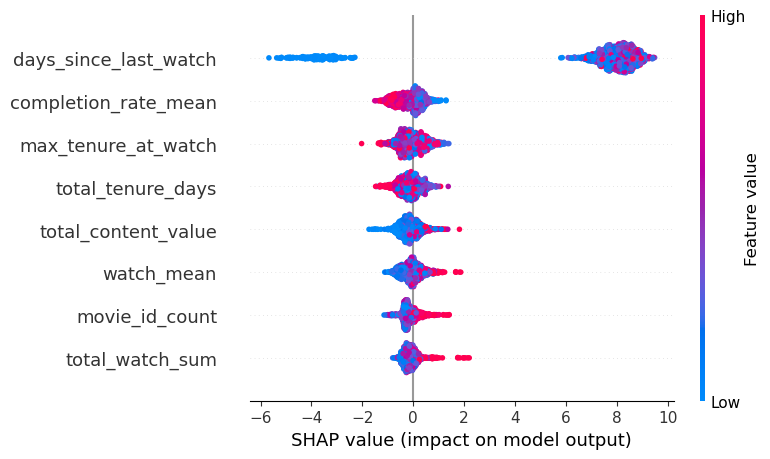

In [185]:
import shap

# Create SHAP Explainer and pass the XGBoost model 
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP value
shap_values = explainer.shap_values(X_test_scaled)

# Make summary plot to show which variables were important factors for decisions
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [186]:
# Calculate correlations
correlations = final_user_df.corr(numeric_only=True)['churn_risk'].sort_values()

print("The correlation between churn risk and other factors")
print(correlations)

The correlation between churn risk and other factors
watch_decline_ratio     -0.809173
recent_7d_watch_sum     -0.721644
max_tenure_at_watch     -0.087104
movie_id_count          -0.046969
completion_rate_mean    -0.011051
total_watch_sum         -0.009285
is_active               -0.005959
monthly_spend           -0.005077
age                      0.000525
total_content_value      0.003740
household_size           0.006953
total_tenure_days        0.016730
watch_mean               0.034501
days_since_last_watch    0.277764
churn_risk               1.000000
Name: churn_risk, dtype: float64


### pull basic user information from the user table, how many unique users do we have and what is the time period we are looking at
